## Nuclei Segmentation and Custom Binning of Visium HD Gene Expression Data

https://www.10xgenomics.com/analysis-guides/segmentation-visium-hd

### Analysis Guide Data Download Links
You can download the data for this Analysis Guide from our public datasets. The mouse small intestine data is available [here](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-intestine).

For this tutorial you will need the following files.

- 2x2 µm filtered barcode matrix (_filtered_feature_bc_matrix.h5_)
    - This file is located in the `/outs/binned_outputs/square_002um `directory of a completed Space Ranger run.
    - The filtered_feature_bc_matrix.h5 is an HDF5 formatted file where the number of UMIs associated with a feature or gene is stored in the rows of a matrix and each column of the matrix is a barcode.

- Parquet tissue position matrix (_tissue_positions.parquet_)
    - This files is located in the `/outs/binned_outputs/square_002um/spatial` directory of a completed Space Ranger run.
    - The tissue_positions.parquet file contains a table of the location of each 2x2 µm barcode square where each column is a barcode.

- High-resolution mouse intestine image (_Visium_HD_Mouse_Small_Intestine_tissue_image.btf_)
    - This is an image generated by the user using a microscope.
    - The name and location of this file is user defined.
    - The time to transfer a high-resolution image can vary depending on internet access, and it may take a significant amount of time due to the file's size.
    
The _filtered_feature_bc_matrix.h5_ and _tissue_positions.parquet_ files are packaged together in our public dataset in the [2x2 µm square outputs](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz). The high-resolution H&E microscope image of the mouse intestine is avaible at [this link](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_tissue_image.btf). If you are running the analysis on a server, you can use the command line below to download the two files. Once the files are downloaded, copy them into the same directory.

### Library Import and Juypter Notebook Setup

The following code block imports the required Python Libraries and configures the image plotting of the Juypter notebook. Comment out the lines beginning with "%" if copying and pasting into one Python script.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import geopandas as gpd
import scanpy as sc
import imageio # to read png

from tifffile import imread, imwrite
from csbdeep.utils import normalize
from stardist.models import StarDist2D
from shapely.geometry import Polygon, Point
from scipy import sparse
from matplotlib.colors import ListedColormap

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/home/chananchidas/miniconda3/envs/stardist-env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/stardist-env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/stardist-env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/stardist-env/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/chananchidas/miniconda3/envs/stardist-env/lib/py

### Data Visualization Helper Functions

We define functions to help with plotting results in the next code block.

In [15]:
# General image plotting functions
def plot_mask_and_save_image(title, gdf, img, cmap, output_name=None, bbox=None):
    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])
        # Filter for polygons in the box
        intersects_bbox = gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = gdf[intersects_bbox]
    else:
        filtered_gdf=gdf

    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(cmap=cmap, ax=axes[1])
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))


    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()
        
# Create plot_mask function that is identical to plot_mask_and_save_image but instead takes in axis and returns the plot
def plot_mask_with_axis(title, gdf, cmap, ax, bbox=None):
    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])
        # Filter for polygons in the box
        intersects_bbox = gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = gdf[intersects_bbox]
    else:
        filtered_gdf=gdf

    # Plot the filtered polygons on the given axis
    filtered_gdf.plot(cmap=cmap, ax=ax)
    ax.set_title(title)
    ax.axis('off')
    
    return


def plot_gene_and_save_image(title, gdf, gene, img, adata, bbox=None, output_name=None):

    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])


    # Find a gene of interest and merge with the geodataframe
    gene_expression = adata[:, gene].to_df()
    gene_expression['id'] = gene_expression.index
    merged_gdf = gdf.merge(gene_expression, left_on='id', right_on='id')

    if bbox is not None:
        # Filter for polygons in the box
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(column=gene, cmap='inferno', legend=True, ax=axes[1])
    axes[1].set_title(gene)
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))

    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()

def plot_clusters_and_save_image(title, gdf, img, adata, bbox=None, color_by_obs=None, output_name=None, color_list=None):
    color_list=["#7f0000","#808000","#483d8b","#008000","#bc8f8f","#008b8b","#4682b4","#000080","#d2691e","#9acd32","#8fbc8f","#800080","#b03060","#ff4500","#ffa500","#ffff00","#00ff00","#8a2be2","#00ff7f","#dc143c","#00ffff","#0000ff","#ff00ff","#1e90ff","#f0e68c","#90ee90","#add8e6","#ff1493","#7b68ee","#ee82ee"]
    if bbox is not None:
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])

    unique_values = adata.obs[color_by_obs].astype('category').cat.categories
    num_categories = len(unique_values)

    if color_list is not None and len(color_list) >= num_categories:
        custom_cmap = ListedColormap(color_list[:num_categories], name='custom_cmap')
    else:
        # Use default tab20 colors if color_list is insufficient
        tab20_colors = plt.cm.tab20.colors[:num_categories]
        custom_cmap = ListedColormap(tab20_colors, name='custom_tab20_cmap')

    merged_gdf = gdf.merge(adata.obs[color_by_obs].astype('category'), left_on='id', right_index=True)

    if bbox is not None:
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    # Plot the filtered polygons on the second axis
    plot = filtered_gdf.plot(column=color_by_obs, cmap=custom_cmap, ax=axes[1], legend=True)
    axes[1].set_title(color_by_obs)
    legend = axes[1].get_legend()
    legend.set_bbox_to_anchor((1.05, 1))
    axes[1].axis('off')

    # Move legend outside the plot
    plot.get_legend().set_bbox_to_anchor((1.25, 1))

    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')
    else:
        plt.show()

# Plotting function for nuclei area distribution
def plot_nuclei_area(gdf,area_cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    # Plot the histograms
    axs[0].hist(gdf['area'], bins=50, edgecolor='black')
    axs[0].set_title('Nuclei Area')

    axs[1].hist(gdf[gdf['area'] < area_cut_off]['area'], bins=50, edgecolor='black')
    axs[1].set_title('Nuclei Area Filtered:'+str(area_cut_off))

    plt.tight_layout()
    plt.show()

# Total UMI distribution plotting function
def total_umi(adata_, cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    axs[0].boxplot(adata_.obs["total_counts"], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[0].set_title('Total Counts')

    # Box plot after filtering
    axs[1].boxplot(adata_.obs["total_counts"][adata_.obs["total_counts"] > cut_off], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[1].set_title('Total Counts > ' + str(cut_off))

    # Remove y-axis ticks and labels
    for ax in axs:
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()


### Nuclei Mask and GeoDataframe Creation

In the following code block, change the file path to the location of the high-resolution image. After importing the image, it is percentile normalized. Adjust the min and max percentile parameters as needed for other images by assessing the image mask for accuracy. Percentile normalization scales pixel values by the specified min and max percentiles.

In [3]:
# Load the image file
# Change dir_base as needed to the directory where the downloaded example data is stored
dir_base = '/home/chananchidas/visium-hd/data/Visium_HD_SmallIntestine/'
plot_dir = "/home/chananchidas/visium-hd/visium_hd_smallintestine/plots/"

btf_filename = 'Visium_HD_Mouse_Small_Intestine_tissue_image.btf'
filename = 'binned_outputs/square_002um/spatial/tissue_hires_image.png'

btf_img = imread(dir_base + btf_filename)
img = imageio.imread(dir_base+filename)

# Get scale factor by dividing the size of the btf image by the size of the png image
scale_factor = btf_img.shape[0] / img.shape[0]
print("scale_factor:", scale_factor)
del btf_img

# Load the pretrained model
model = StarDist2D.from_pretrained('2D_versatile_he')

# Percentile normalization of the image
# Adjust min_percentile and max_percentile as needed
min_percentile = 5
max_percentile = 95
img = normalize(img, min_percentile, max_percentile)

205464143.py (10): Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.


scale_factor: 3.935964125560538
Found model '2D_versatile_he' for 'StarDist2D'.


I0000 00:00:1731662655.057184  150427 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731662655.110443  150427 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731662655.117469  150427 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731662655.128011  150427 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


Execute the code block below to create the nuclei segmentation mask. This step has a long runtime and it will vary significantly depending on the chosen parameter settings. The nms threshold (nms_thresh) is set to a small number to reduce the probability of nuclei overlap. The nms_thresh parameter may require adjustment for different images. Also, it may be necessary to adjust the probability threshold (prob_thresh) for different images. Larger prob_thresh values will result in fewer segmented objects. The optimal values for prob_thresh and nm_thresh will depend on visual assessment of the nuclei segmentation mask.

100%|██████████| 16/16 [00:02<00:00,  6.71it/s]


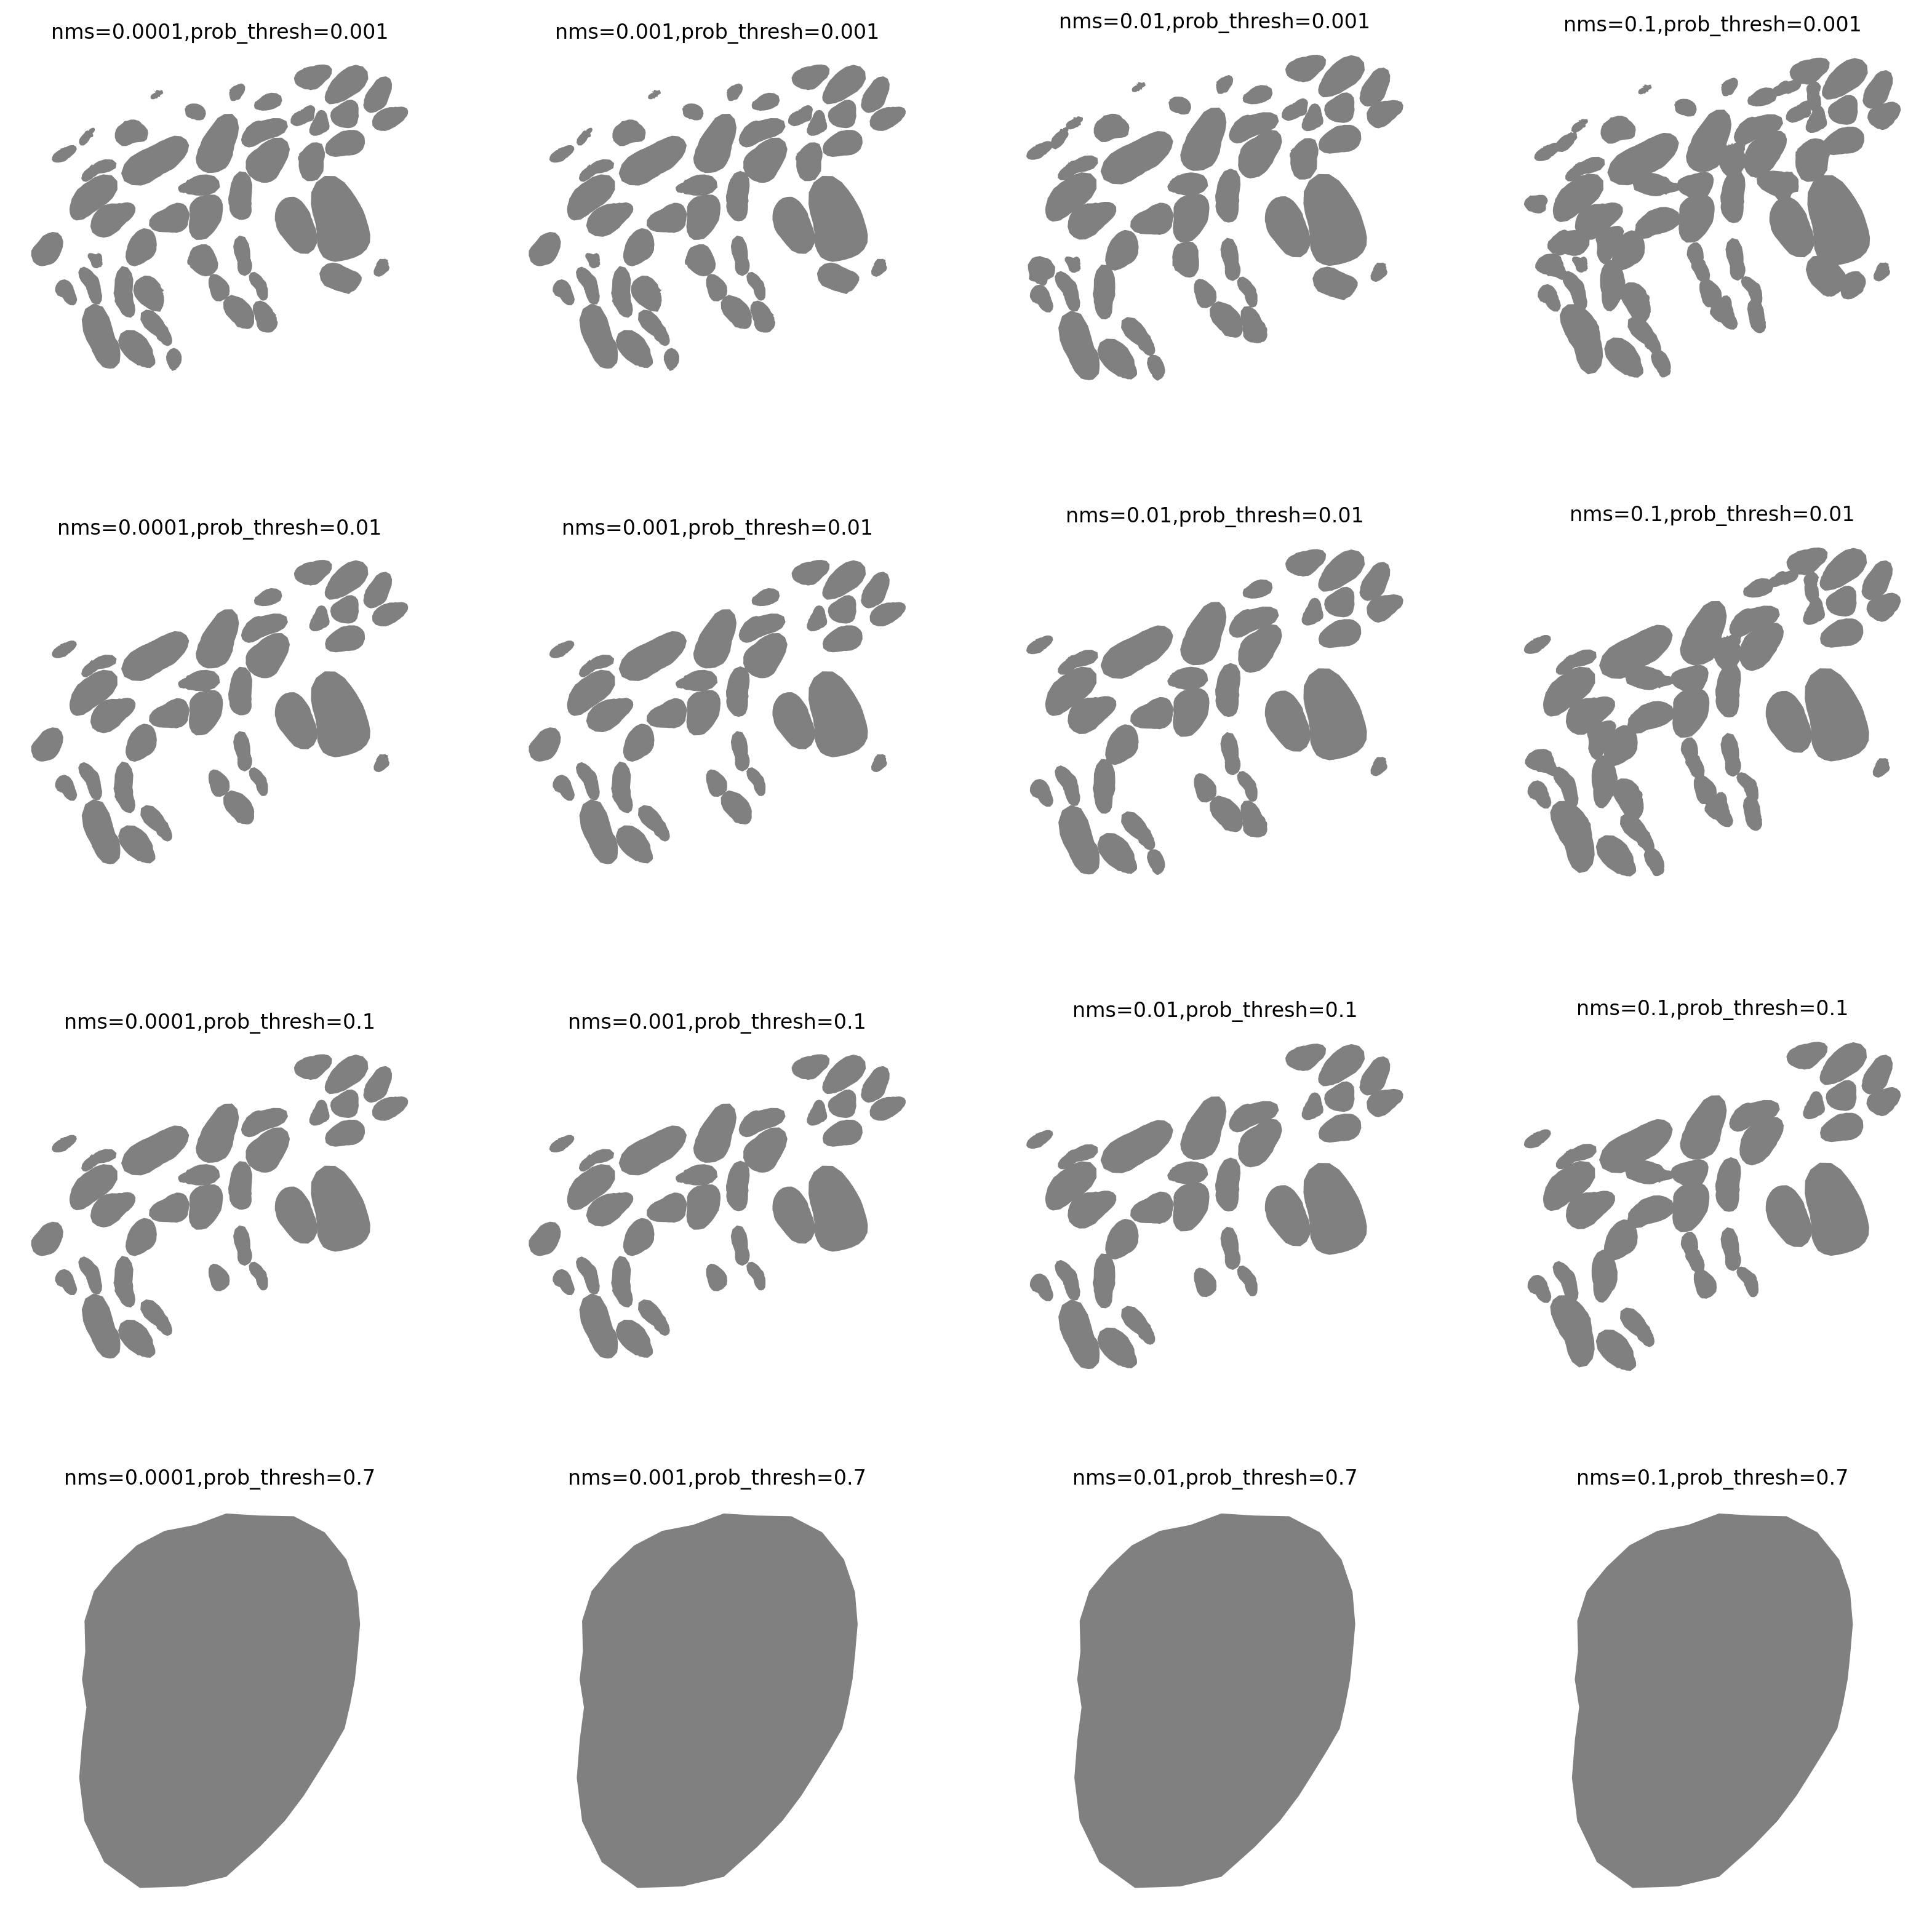

In [20]:
# Create a 4x4 plot that will test prob_thresh from (0.001, 0.01, 0.1, and 0.7) and nms_thresh from (0.0001, 0.001, 0.01, and 0.1)
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

cmap=ListedColormap(['grey'])
bbox_scaled = [round(x/scale_factor) for x in  (12844,7700,13760,8664)]

# Create a list of prob_thresh and nms_thresh values
prob_thresh_values = [0.001, 0.01, 0.1, 0.7]
nms_thresh_values = [0.0001, 0.001, 0.01, 0.1]

for i, prob_thresh in enumerate(prob_thresh_values):
    for j, nms_thresh in enumerate(nms_thresh_values):
        # Predict the mask
        labels, polys = model.predict_instances(img, prob_thresh=prob_thresh, nms_thresh=nms_thresh, n_tiles=(4,4,1))

        # Creating a list to store Polygon geometries
        geometries = []

        # Iterating through each nuclei in the 'polys' DataFrame
        for nuclei in range(len(polys['coord'])):

            # Extracting coordinates for the current nuclei and converting them to (y, x) format
            coords = [(y, x) for x, y in zip(polys['coord'][nuclei][0], polys['coord'][nuclei][1])]

            # Creating a Polygon geometry from the coordinates
            geometries.append(Polygon(coords))

        # Creating a GeoDataFrame using the Polygon geometries
        gdf = gpd.GeoDataFrame(geometry=geometries)
        gdf['id'] = [f"ID_{k+1}" for k, _ in enumerate(gdf.index)]
        
        plot_mask_with_axis(title="nms={},prob_thresh={}".format(nms_thresh,prob_thresh),
                            gdf=gdf,bbox=bbox_scaled,cmap=cmap,ax=axs[i,j])
